In [50]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def gauss_seidel(A: np.ndarray, b: np.ndarray, x0: np.ndarray, x_tr: np.ndarray, tol=1e-10, max_iter=1000):
    errors = []
    n = len(b)
    x = x0.copy()

    for _ in range(max_iter):
        x_new = x.copy()
        for i in range(n):
            sum1, sum2 = 0, 0
            for j in range(i): sum1 += A[i, j] * x_new[j]
            for j in range(i+1, n): sum2 += A[i, j] * x[j]
           
            x_new[i] = (b[i] - sum1 - sum2) / A[i, i]

        errors.append(np.linalg.norm(x_new - x, ord=np.inf))
    
        if np.linalg.norm(x_new - x_tr, ord=np.inf) <= tol:
            print(f"Гаусс-Зейдель: сошелся за {_ + 1} итераций.")
            return x_new, errors

        x = x_new

    print("Максимальное количество итераций достигнуто")
    return x, errors

In [47]:
A = np.array([[2, 1, 0],
              [5, -2, -3],
              [0, 2, 4]], dtype=float)

x_true = np.array([1, 2, 3], dtype=float)
b = A @ x_true

x0 = np.zeros_like(b)

x_pred, errors = gauss_seidel(A, b, x0=x0, x_tr=x_true)
x_pred

Гаусс-Зейдель: сошелся за 38 итераций.


array([1., 2., 3.])

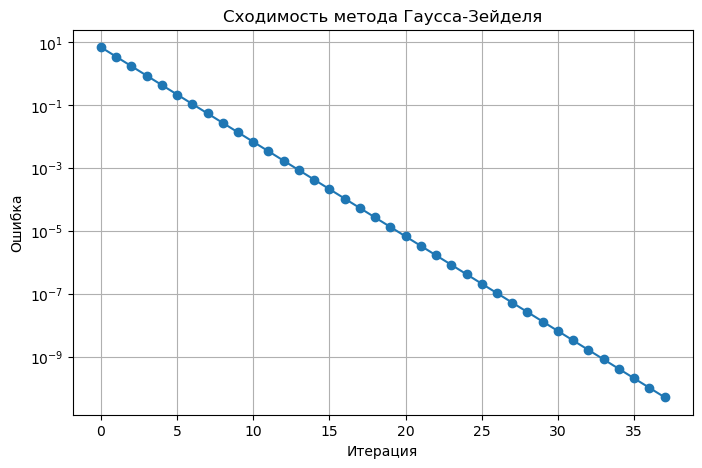

In [48]:
plt.figure(figsize=(8,5))
plt.semilogy(errors, marker='o')
plt.xlabel("Итерация")
plt.ylabel("Ошибка")
plt.title("Сходимость метода Гаусса-Зейделя")
plt.grid(True)
plt.show()